# Child model V&V: LBWSG exposure and relative risks (live sim)

Instantiates an `InteractiveContext` of the child model and checks, against the artifact:

1. the LBWSG category distribution of the born cohort vs GBD birth prevalence
   (baseline scenario), with a per-(sex, category) fuzzy check of the line list,
2. that the distribution shifts the expected way under the intervention scenario
   (maternal iron -> birth weight, effect size from the artifact),
3. the per-simulant relative risks the sim's pipelines assign, by category
   (**expected to fail pre-fix**: the artifact's `relative_risk_interpolator` is scrambled,
   see the knot check in `child_mortality.ipynb`),
4. (skipped until the fix lands) empirical RRs after running the sim through the neonatal period.

Version-free filename by convention: rerun against each model iteration and commit.
Needs the **lsff-simulation** kernel (`.snakemake_envs/simulation` -- the vivarium engine env,
not the artifact env the other V&V notebooks use).

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from loguru import logger

logger.disable("vivarium")  # setup emits benign, timestamped lookup-table warnings that would pollute rerun diffs

from vivarium.artifact import Artifact
from vivarium.engine import InteractiveContext

location = "nigeria"
vehicle = "bouillon"
artifact_dir = f"/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/model1.1/child/{vehicle}/{location}.hdf"
maternal_artifact_dir = f"/mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/model1.1/maternal/{vehicle}/{location}.hdf"
spec_path = "../../../0300_child_sim/src/vivarium_gates_lsff_2026_child/model_specifications/model_spec.yaml"
art = Artifact(artifact_dir)


def make_sim(maternal_scenario):
    sim = InteractiveContext(
        spec_path,
        configuration={
            "input_data": {"artifact_path": artifact_dir},
            "intervention": {"maternal_scenario": maternal_scenario, "child_scenario": "baseline"},
        },
    )
    sim.step()  # every birth date precedes the sim start, so the whole cohort is born on the first step
    return sim


ATTRS = [
    "sex",
    "birth_weight.exposure",
    "gestational_age.exposure",
    "birth_weight_status",
    "effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_affected_unmodeled_relative_risk",
    "effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_affected_unmodeled_relative_risk",
    "maternal_iron_consumption_from_fortification_mcg",
    "baseline_2021_maternal_iron_consumption_from_fortification_mcg",
]

In [2]:
sim_baseline = make_sim("baseline")
pop = sim_baseline.get_population(ATTRS, include_untracked=True)
print(f"{len(pop)} simulants born (seed 0, draw 0); mean birth weight {pop['birth_weight.exposure'].mean():.1f} g")

26619 simulants born (seed 0, draw 0); mean birth weight 3318.8 g


## 1. Exposure distribution vs artifact (baseline)

The sim carries continuous (gestational age, birth weight) from the maternal line list, plus the
in-sim wealth-quintile and iron modifiers. Bin simulants into GBD categories using the bounds in
the artifact's category descriptions (a closed upper bound like `42+]` is treated as unbounded)
and compare the shares against the artifact's birth exposure. Stillbirths (~2.6%) are included,
as in `preg_states.ipynb`.

In [3]:
pat = re.compile(r"\[(\d+), (\d+)(\+?)([\)\]]) wks, \[(\d+), (\d+)(\+?)([\)\]]) g")


def parse_bounds(desc):
    ga_s, ga_e, ga_plus, ga_br, bw_s, bw_e, bw_plus, bw_br = pat.search(desc).groups()
    ga_end = np.inf if (ga_plus or ga_br == "]") else float(ga_e)
    bw_end = np.inf if (bw_plus or bw_br == "]") else float(bw_e)
    return float(ga_s), ga_end, float(bw_s), bw_end


cat_defs = art.load("risk_factor.low_birth_weight_and_short_gestation.categories")
bounds = pd.DataFrame(
    [(cat, *parse_bounds(desc)) for cat, desc in cat_defs.items()],
    columns=["parameter", "ga_start", "ga_end", "bw_start", "bw_end"],
)


def assign_categories(pop):
    cats = pd.Series(np.nan, index=pop.index, dtype=object, name="parameter")
    for _, b in bounds.iterrows():
        in_cat = (
            (pop["gestational_age.exposure"] >= b.ga_start)
            & (pop["gestational_age.exposure"] < b.ga_end)
            & (pop["birth_weight.exposure"] >= b.bw_start)
            & (pop["birth_weight.exposure"] < b.bw_end)
        )
        cats[in_cat] = b.parameter
    # the wealth-quintile birth weight scaling moves a handful of births (~0.03%) into
    # (GA, BW) cells the GBD categories do not tile; drop them from the binned comparison
    print(f"unbinned: {cats.isna().sum()} of {len(cats)}")
    return cats


pop["parameter"] = assign_categories(pop)
pop["input_draw"] = 0  # mean-draw artifact: single draw
exposure = (
    pop.groupby(["input_draw", "parameter"]).size() / pop["parameter"].notna().sum()
).rename("exposure").reset_index()

unbinned: 9 of 26619


In [4]:
# Reference: GBD birth prevalence (age group 164 -- what the maternal sim sampled), from
# the MATERNAL artifact, weighting the sexes by the cohort's own sex mix. The CHILD
# artifact's exposure key holds early/late-neonatal (survivor) prevalence, depleted up to
# ~200x in the extreme-preterm categories -- the wrong yardstick for a birth cohort.
birth_prevalence = (
    Artifact(maternal_artifact_dir)
    .load("risk_factor.low_birth_weight_and_short_gestation.exposure")
    .reset_index()
    .set_index(["sex", "parameter"])
    .draw_0
)
exp = birth_prevalence.unstack("sex")
p_male = (pop.sex == "Male").mean()
exp["draw_0"] = p_male * exp["Male"] + (1 - p_male) * exp["Female"]

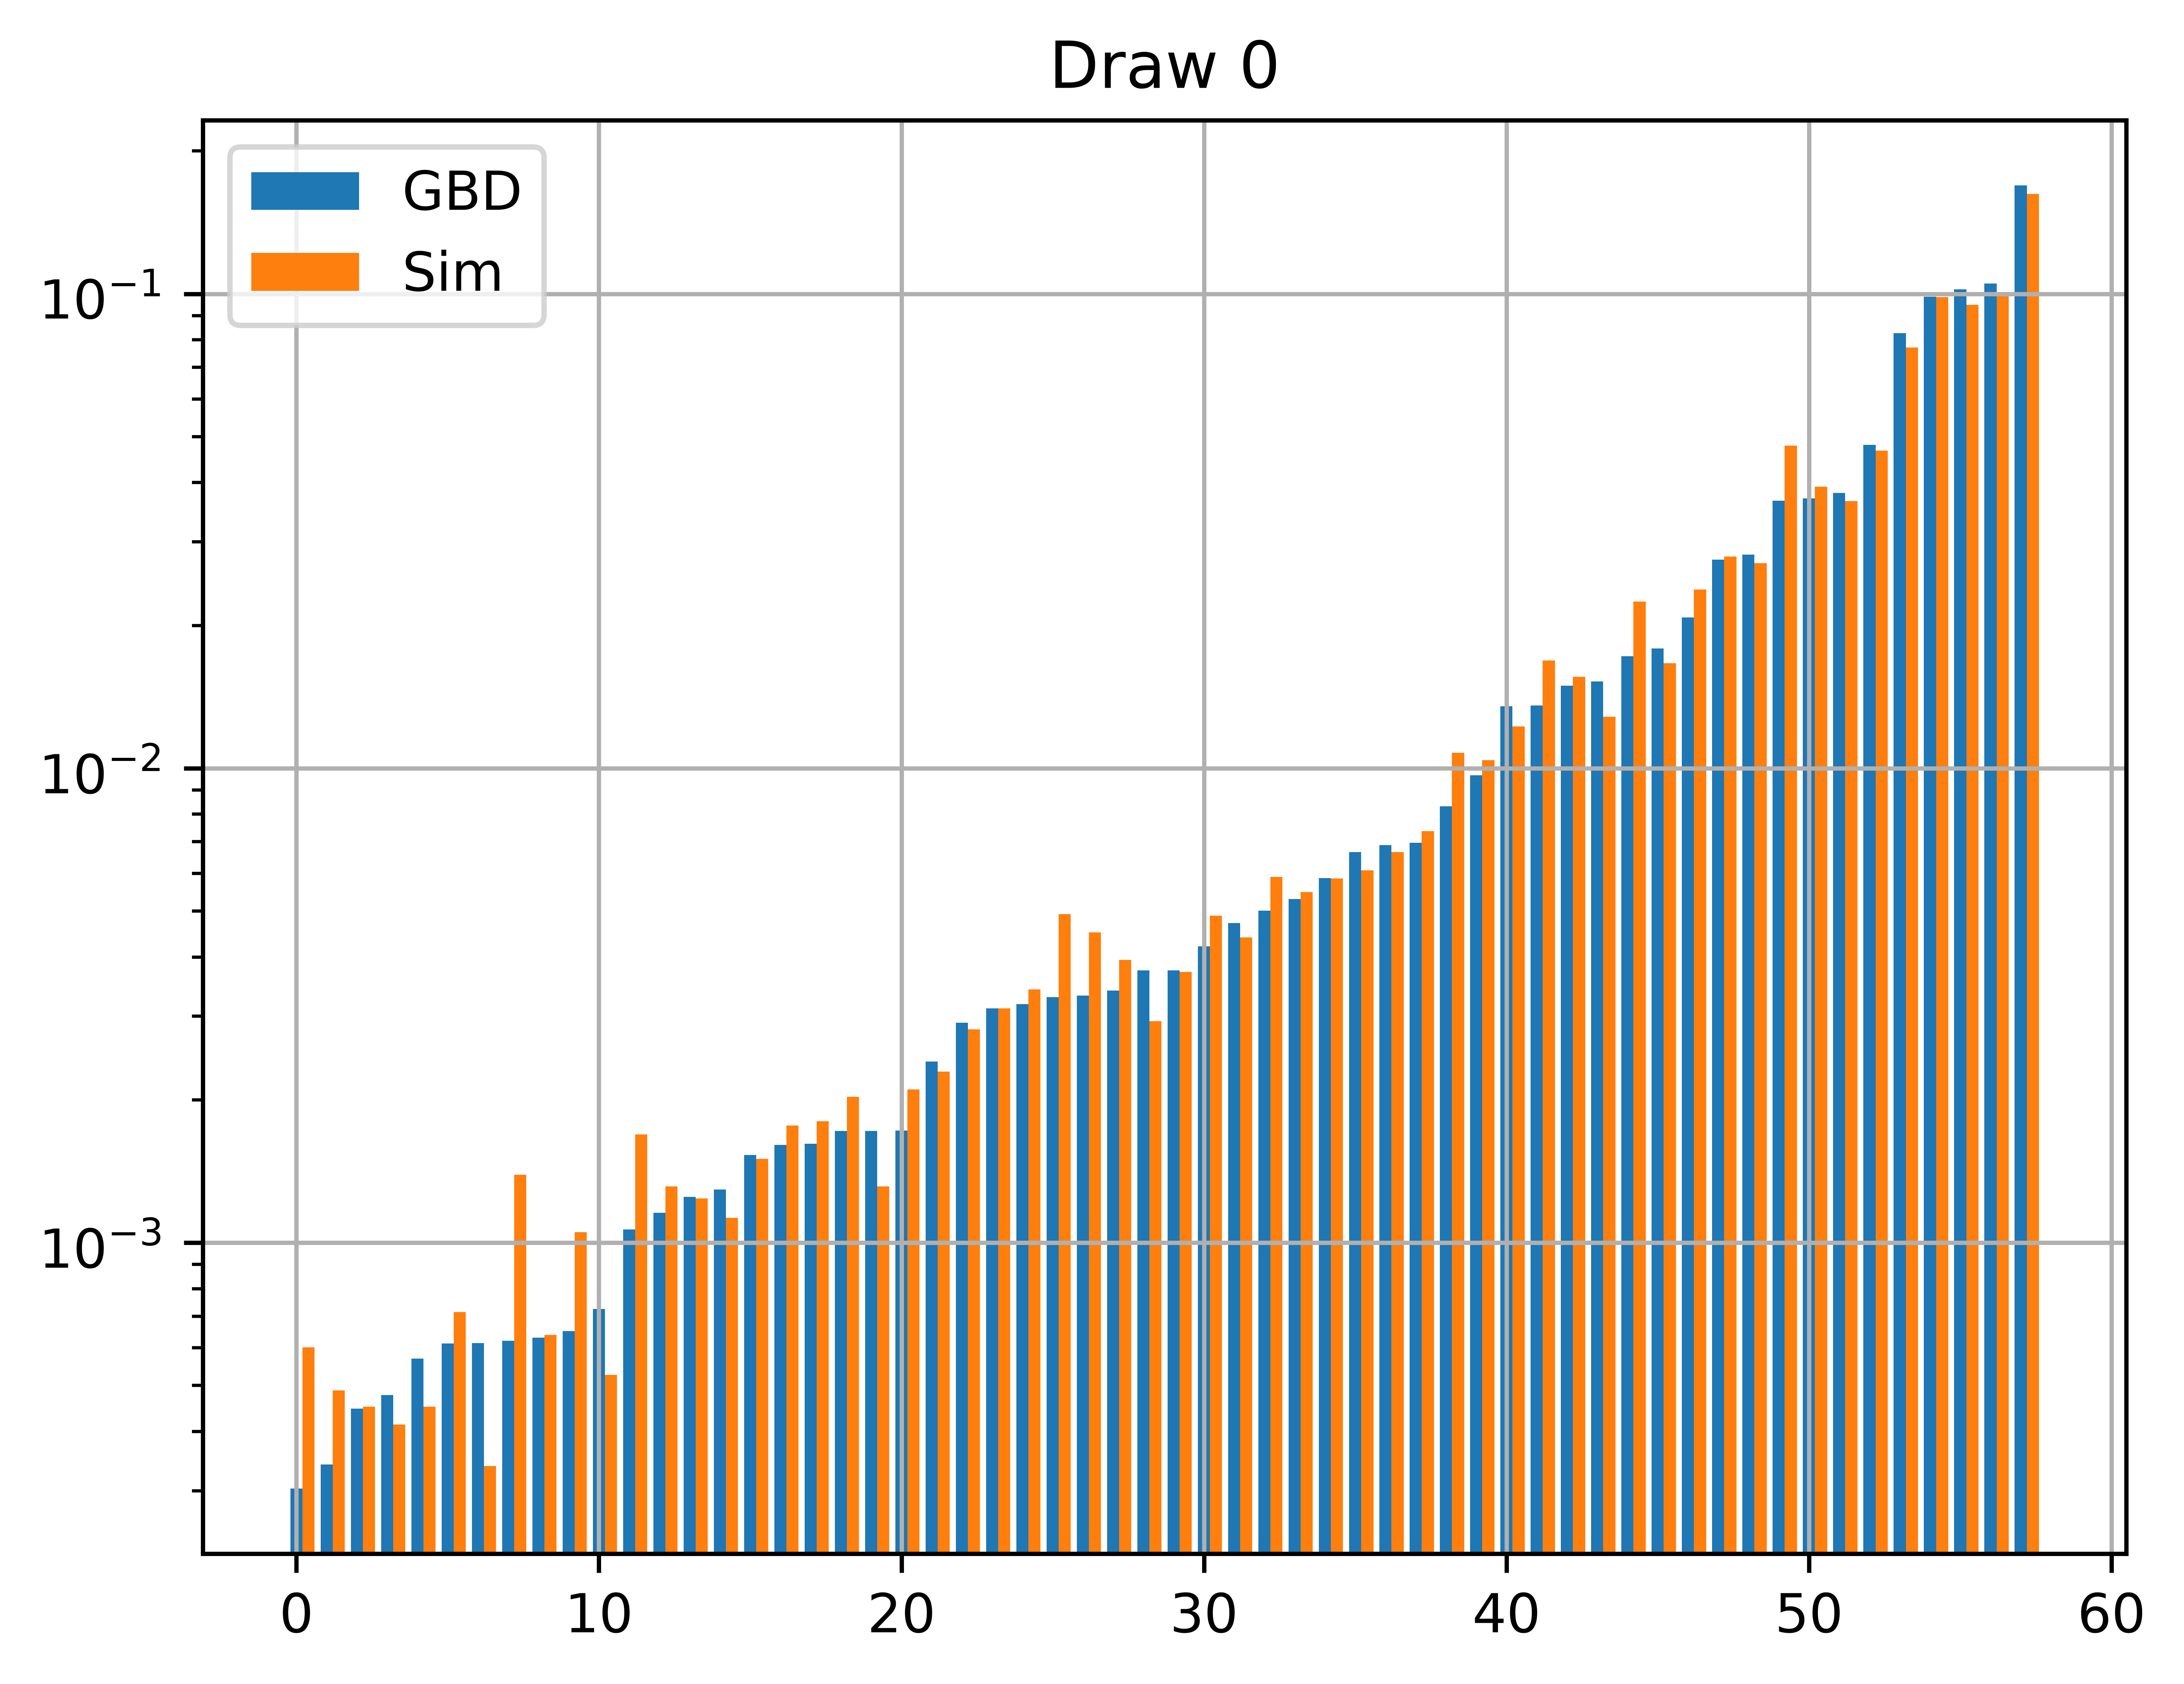

In [5]:
width = 0.4
for draw in exposure.input_draw.unique():
    p = exposure.loc[exposure.input_draw==draw].merge(exp[[f'draw_{draw}']], on='parameter')
    p = p.sort_values(by=f'draw_{draw}').reset_index()
    plt.figure(dpi=1000)
    plt.bar(p.index, p[f'draw_{draw}'], width=width, label='GBD')
    plt.bar(p.index + width, p.exposure, width=width, label='Sim')
    plt.grid()
    plt.legend()
    plt.title(f'Draw {draw}')
    plt.semilogy()

In [6]:
# Formal check of the maternal sampler with the line list itself (pre-modifier values,
# pooled over all 10 seeds, baseline, draw 0): one test per (sex, category) against the
# birth-prevalence target. Same Bayesian hypothesis test as vivarium.validation's
# FuzzyChecker.assert_proportion with an exact target (H0: binomial at the target;
# H1 "bug": Jeffreys beta-binomial; fail at Bayes factor > 100), inlined because the
# simulation env does not ship vivarium.validation. Verified to agree with the real
# checker's verdicts on these data.
from scipy.stats import betabinom, binom

ll = pd.read_hdf(
    artifact_dir, "/population/fertility_data", where="scenario == 'baseline' and input_draw == 0"
).reset_index()
ll["parameter"] = assign_categories(
    ll.rename(columns={"birth_weight": "birth_weight.exposure", "gestational_age": "gestational_age.exposure"})
)
obs = ll.groupby(["sex", "parameter"]).size()
n_sex = ll.groupby("sex").size()

def bayes_factor(k, n, p0):
    return betabinom.pmf(k, n, 0.5, 0.5) / binom.pmf(k, n, p0)


bayes_factors = pd.Series({
    (sex, cat): bayes_factor(int(obs.get((sex, cat), 0)), int(n_sex[sex]), tgt)
    for (sex, cat), tgt in birth_prevalence.items()
})
n_fail = (bayes_factors > 100).sum()
print(f"{len(ll)} line-list births; {n_fail} of {len(bayes_factors)} (sex, category) "
      f"proportions fail at Bayes factor > 100; max BF = {bayes_factors.max():.3g}")
assert n_fail == 0

unbinned: 0 of 267264
267264 line-list births; 0 of 116 (sex, category) proportions fail at Bayes factor > 100; max BF = 0.108


The sim tracks GBD birth prevalence over ~4 orders of magnitude including the extreme-preterm
tail, and every (sex, category) proportion of the line list passes the fuzzy check.

Two notes for future readers:

- **The reference matters.** The first version of this notebook compared against the child
  artifact's exposure key, which is early/late-neonatal (survivor) prevalence -- depleted up to
  ~200x in the highest-mortality categories (cat2: 3e-6 at ENN vs 6.3e-4 at birth). Against that
  yardstick a birth cohort shows a spurious ~220x tail "excess" (Bayes factor ~1e180); against
  the birth-prevalence target it passes cleanly.
- Within-category placement is uniform, so implausible continuous values (GA < 20 wks -- the
  "GAs that are too low" note in `preg_states.ipynb`) occur by construction inside cat2's
  [0, 24) wks box. That only matters through the continuous RR interpolator, not the
  categorical shares.

## 2. Intervention scenario: birth weight shift

The line list carries identical raw (GA, BW) in both scenarios (common random numbers); only the
iron dose differs, and the child sim applies `dose_mg x effect_size` to birth weight. So the mean
shift has an exact expectation, and every simulant who changes category should move to a heavier
birth weight bin (up to the tiny renormalization the wealth-quintile modifier applies).

In [7]:
sim_intervention = make_sim("intervention")
pop_int = sim_intervention.get_population(ATTRS, include_untracked=True)
pop_int["parameter"] = assign_categories(pop_int)

effect_size = art.load("risk.iron_fortification.effect_size").loc[vehicle, "value"]  # g BW per mg daily iron
d_iron_mg = (
    pop_int["maternal_iron_consumption_from_fortification_mcg"]
    - pop["maternal_iron_consumption_from_fortification_mcg"]
) / 1_000
observed = pop_int["birth_weight.exposure"].mean() - pop["birth_weight.exposure"].mean()
print(f"mean birth weight shift: observed {observed:+.2f} g, expected {d_iron_mg.mean() * effect_size:+.2f} g")
print(f"covered by iron fortification (intervention): {(pop_int['maternal_iron_consumption_from_fortification_mcg'] > 0).mean():.1%}")
print(
    f"low birth weight fraction: baseline {(pop['birth_weight_status'] == 'low_birth_weight').mean():.4f},",
    f"intervention {(pop_int['birth_weight_status'] == 'low_birth_weight').mean():.4f}",
)

both_binned = pop["parameter"].notna() & pop_int["parameter"].notna()
moved = both_binned & (pop["parameter"] != pop_int["parameter"])
bw_start = bounds.set_index("parameter")["bw_start"]
heavier = bw_start[pop_int.loc[moved, "parameter"]].values > bw_start[pop.loc[moved, "parameter"]].values
print(f"category changed for {moved.sum()} simulants ({moved.mean():.2%}); moved to a heavier BW bin: {heavier.mean():.1%}")

unbinned: 7 of 26619
mean birth weight shift: observed +11.65 g, expected +11.65 g
covered by iron fortification (intervention): 77.2%
low birth weight fraction: baseline 0.1232, intervention 0.1185
category changed for 565 simulants (2.12%); moved to a heavier BW bin: 100.0%


All three checks pass: the mean shift matches the analytic expectation exactly (the wealth-quintile
renormalization preserves the mean by construction), the low birth weight fraction falls, and every
simulant who changed category moved to a heavier birth weight bin.

## 3. Relative risks in the sim's pipelines vs artifact

`LBWSGRiskEffect` gives each simulant an RR by evaluating the artifact's 2-D interpolator at their
(GA, BW). Group those by category and compare with the artifact's raw category RRs. Post-fix the
bars should track closely (residual = within-category interpolation spread); **pre-fix this fails**
because the interpolator was built from scrambled (midpoint, RR) pairs -- `child_mortality.ipynb`
measures max |log error| = 4.19 at the knots.

early_neonatal Male: max |log(sim/GBD)| = 3.62
early_neonatal Female: max |log(sim/GBD)| = 3.67
late_neonatal Male: max |log(sim/GBD)| = 2.49
late_neonatal Female: max |log(sim/GBD)| = 2.73


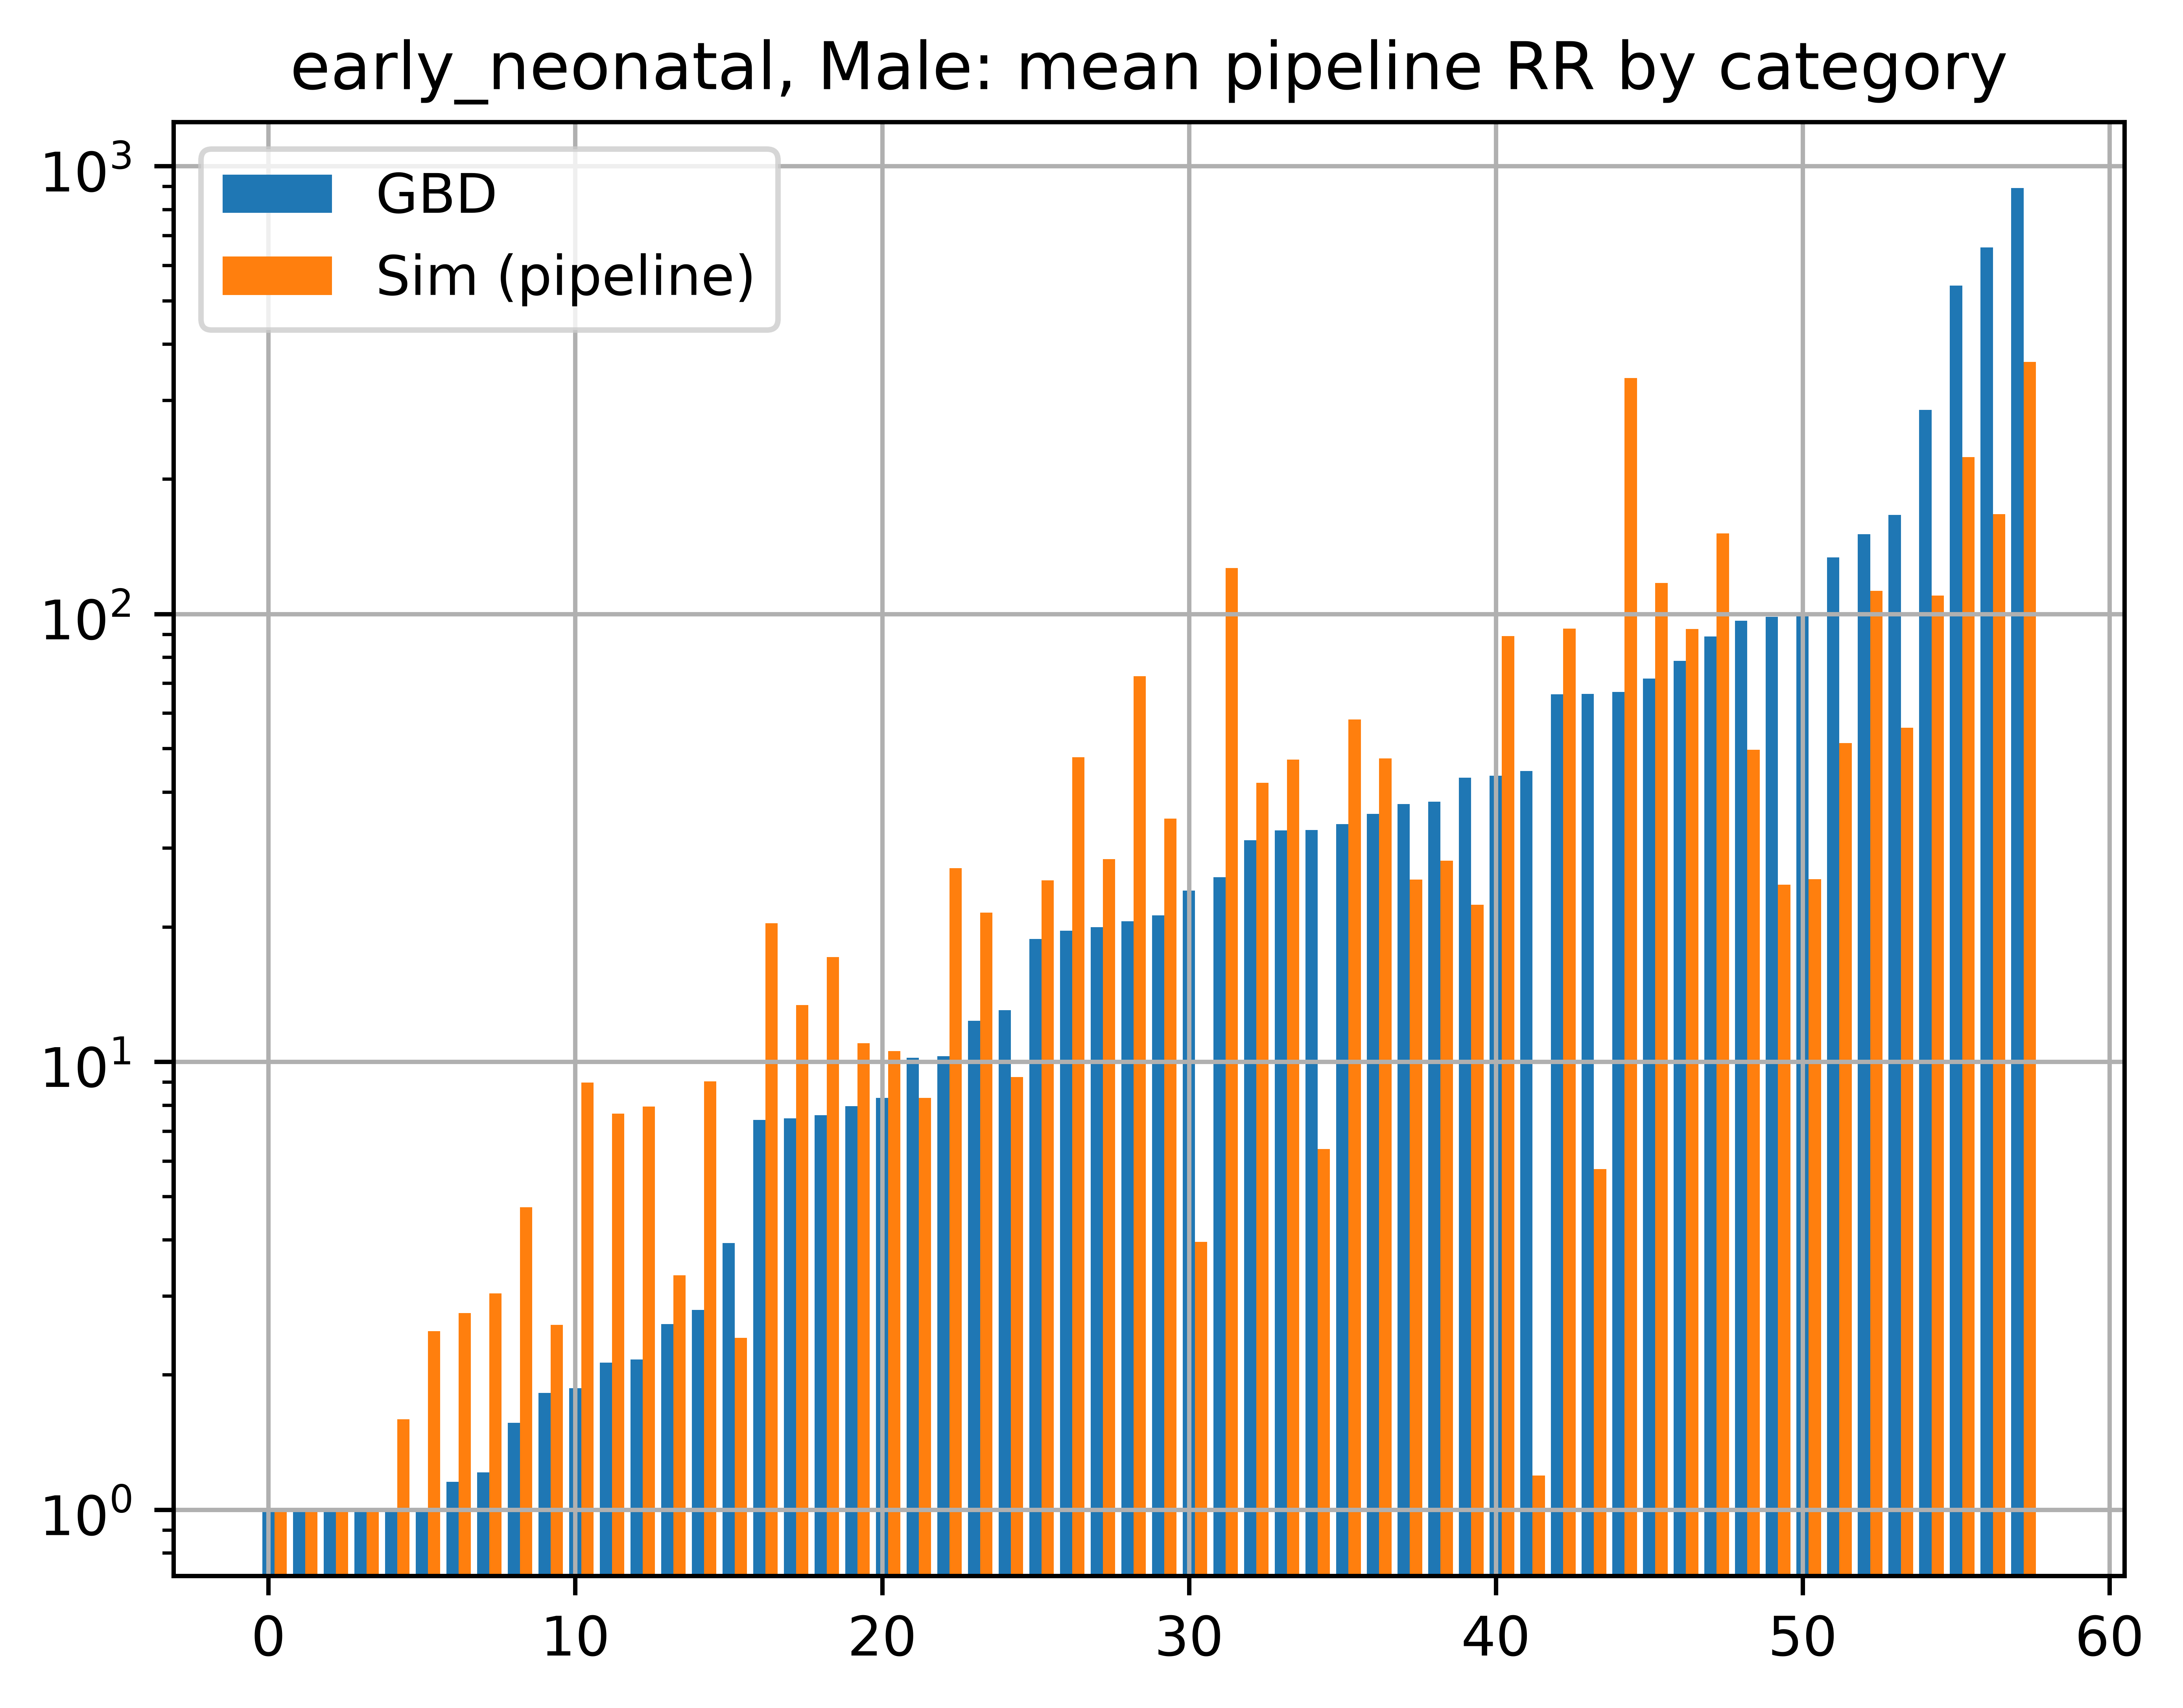

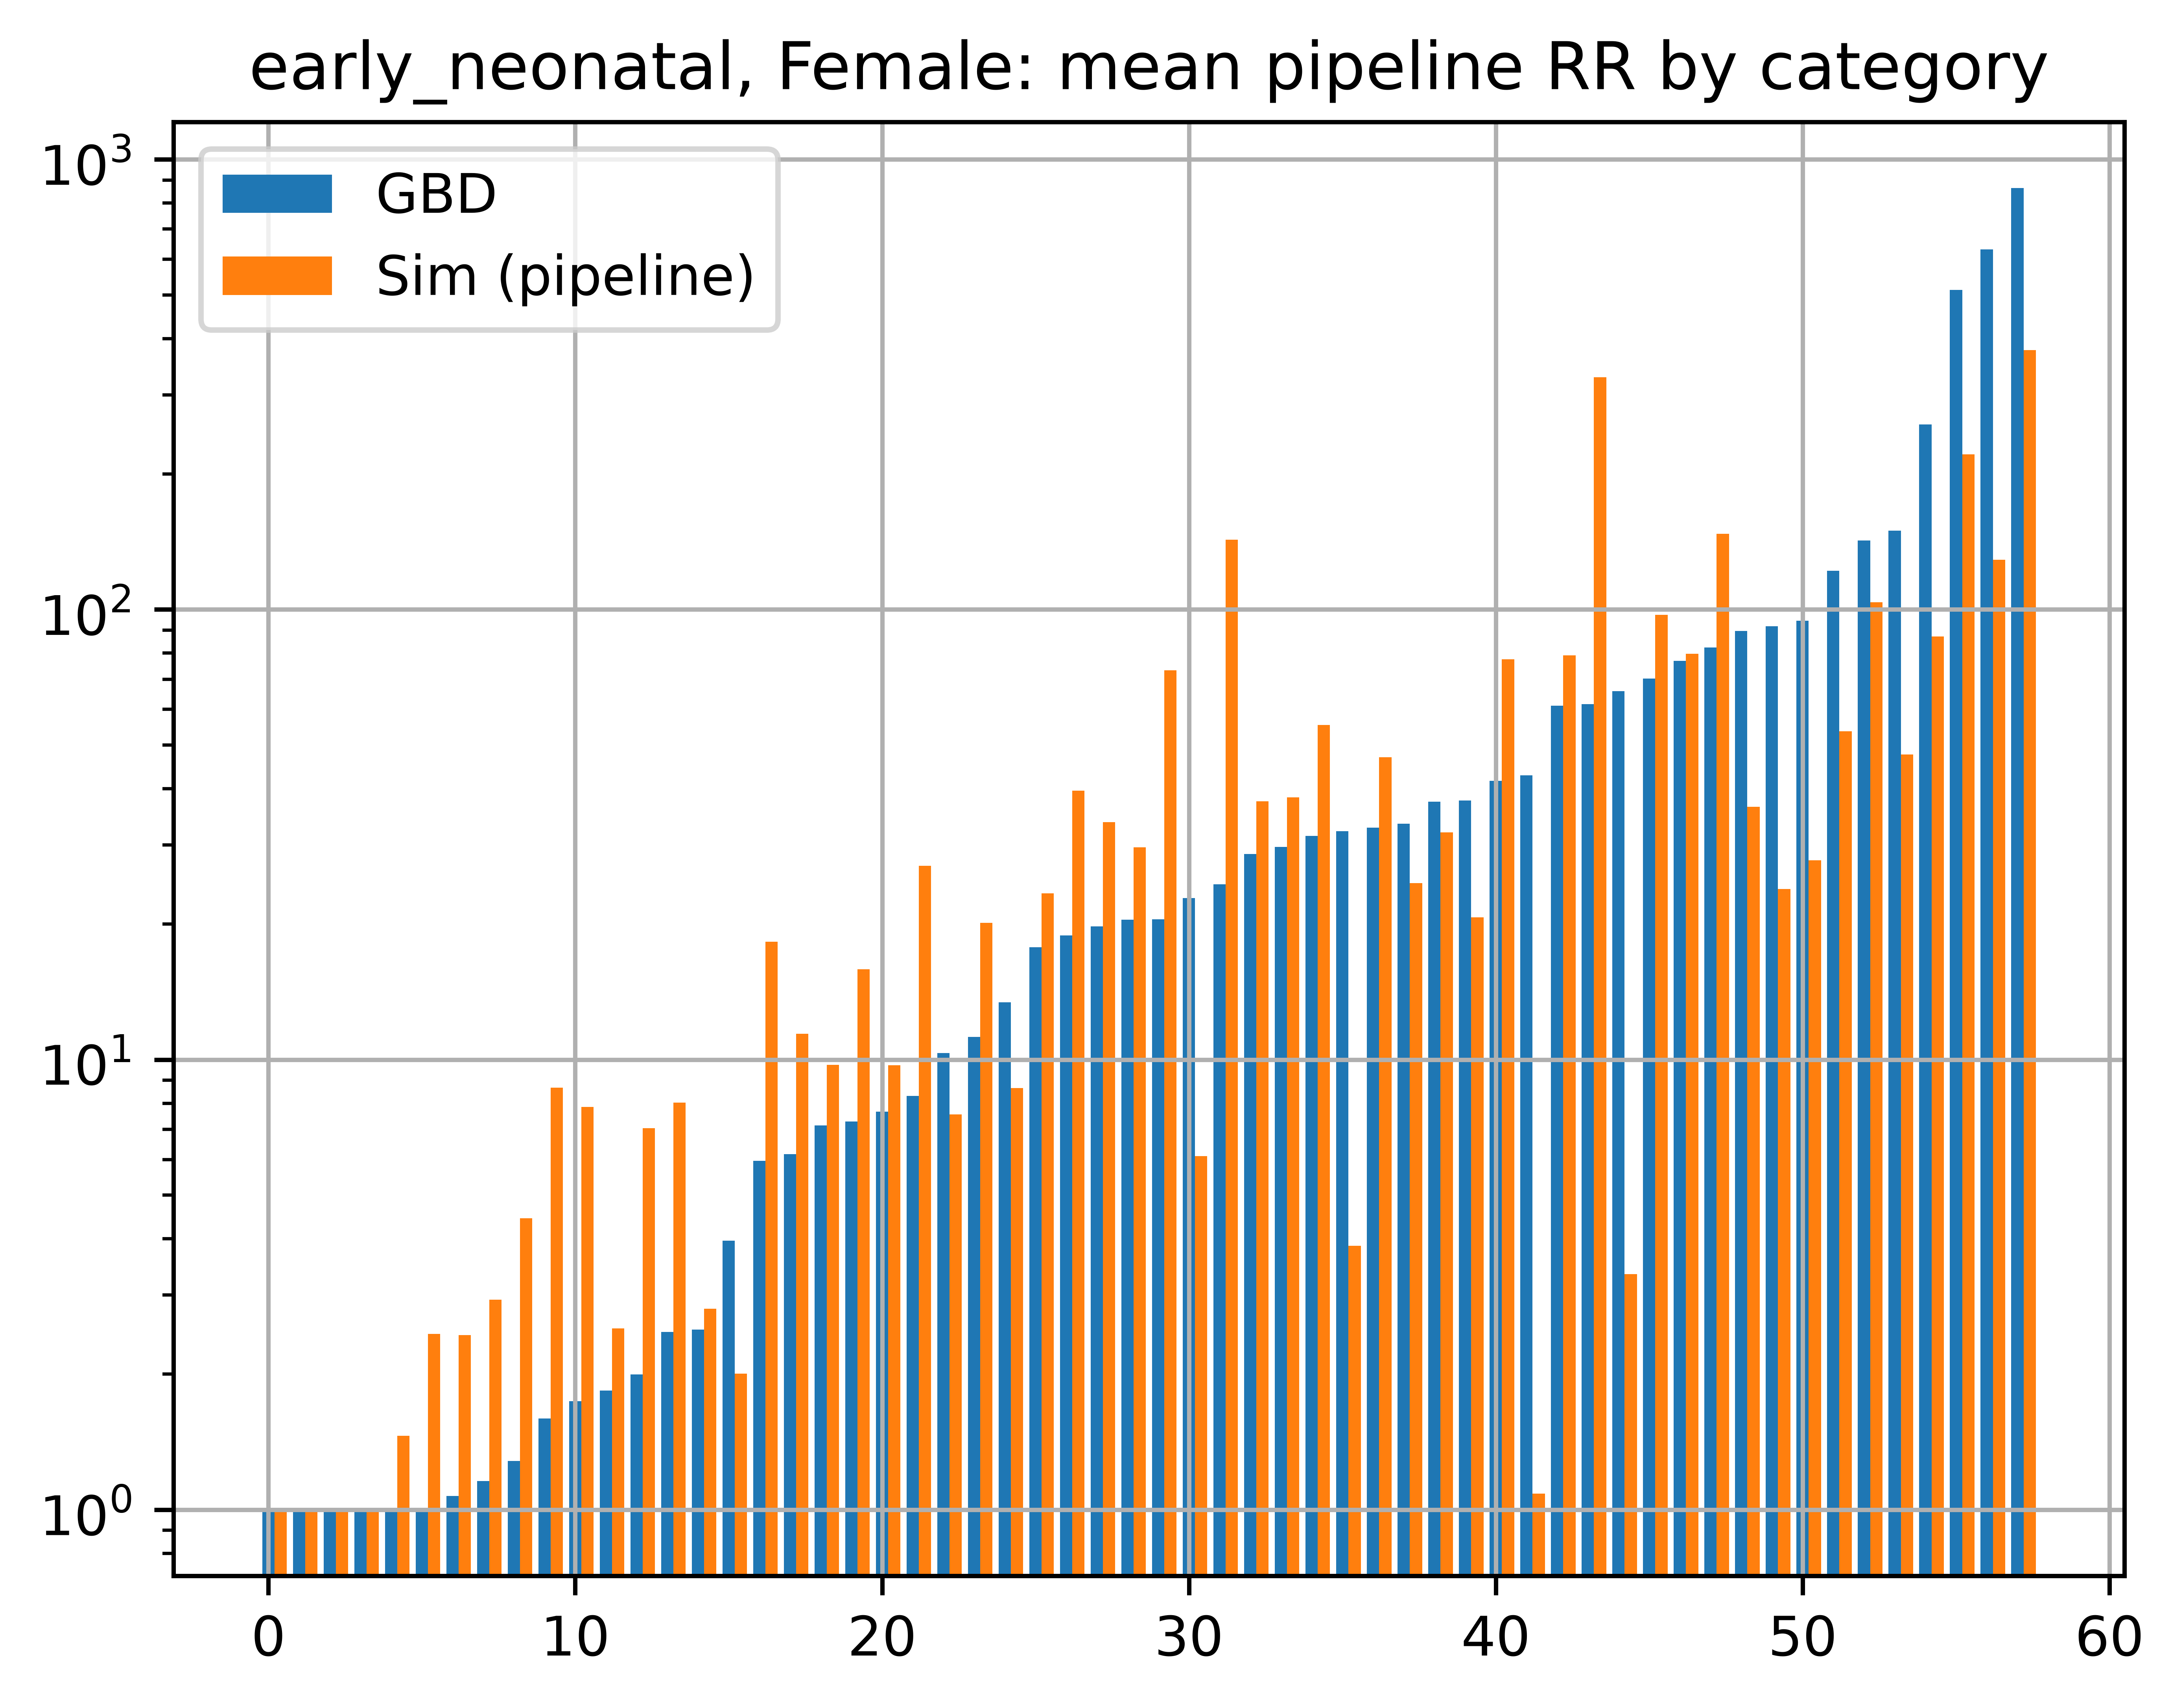

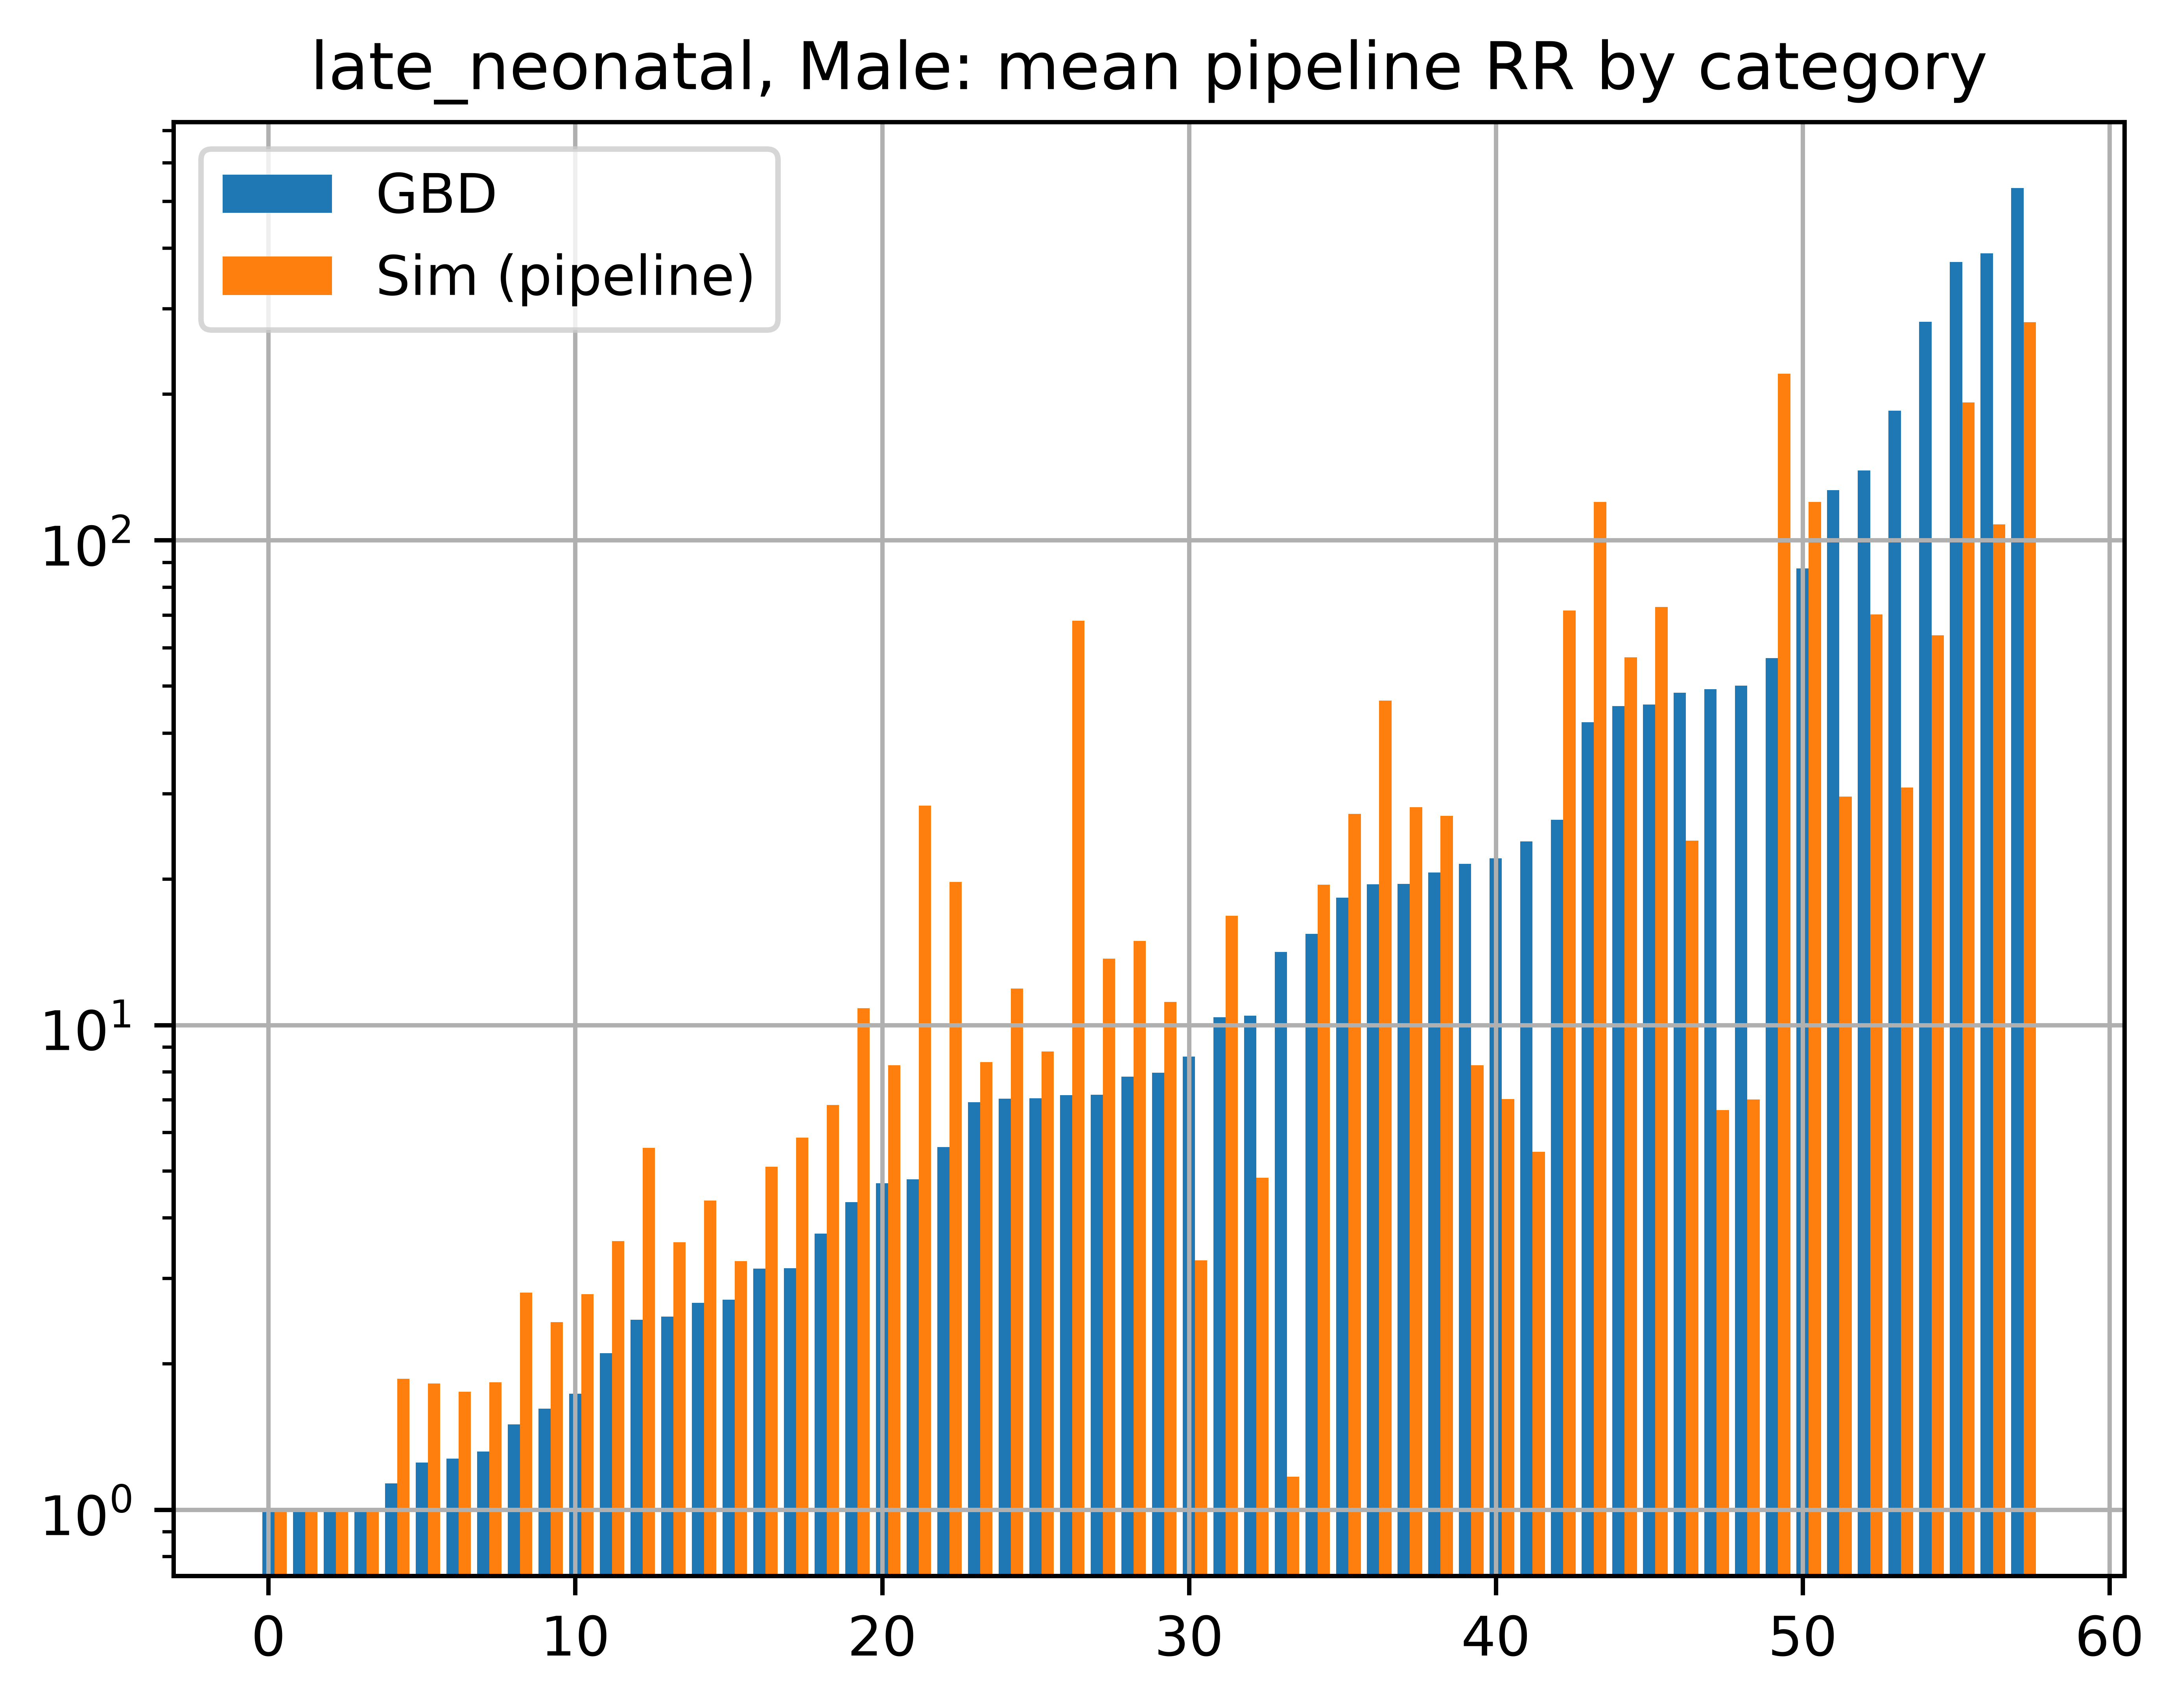

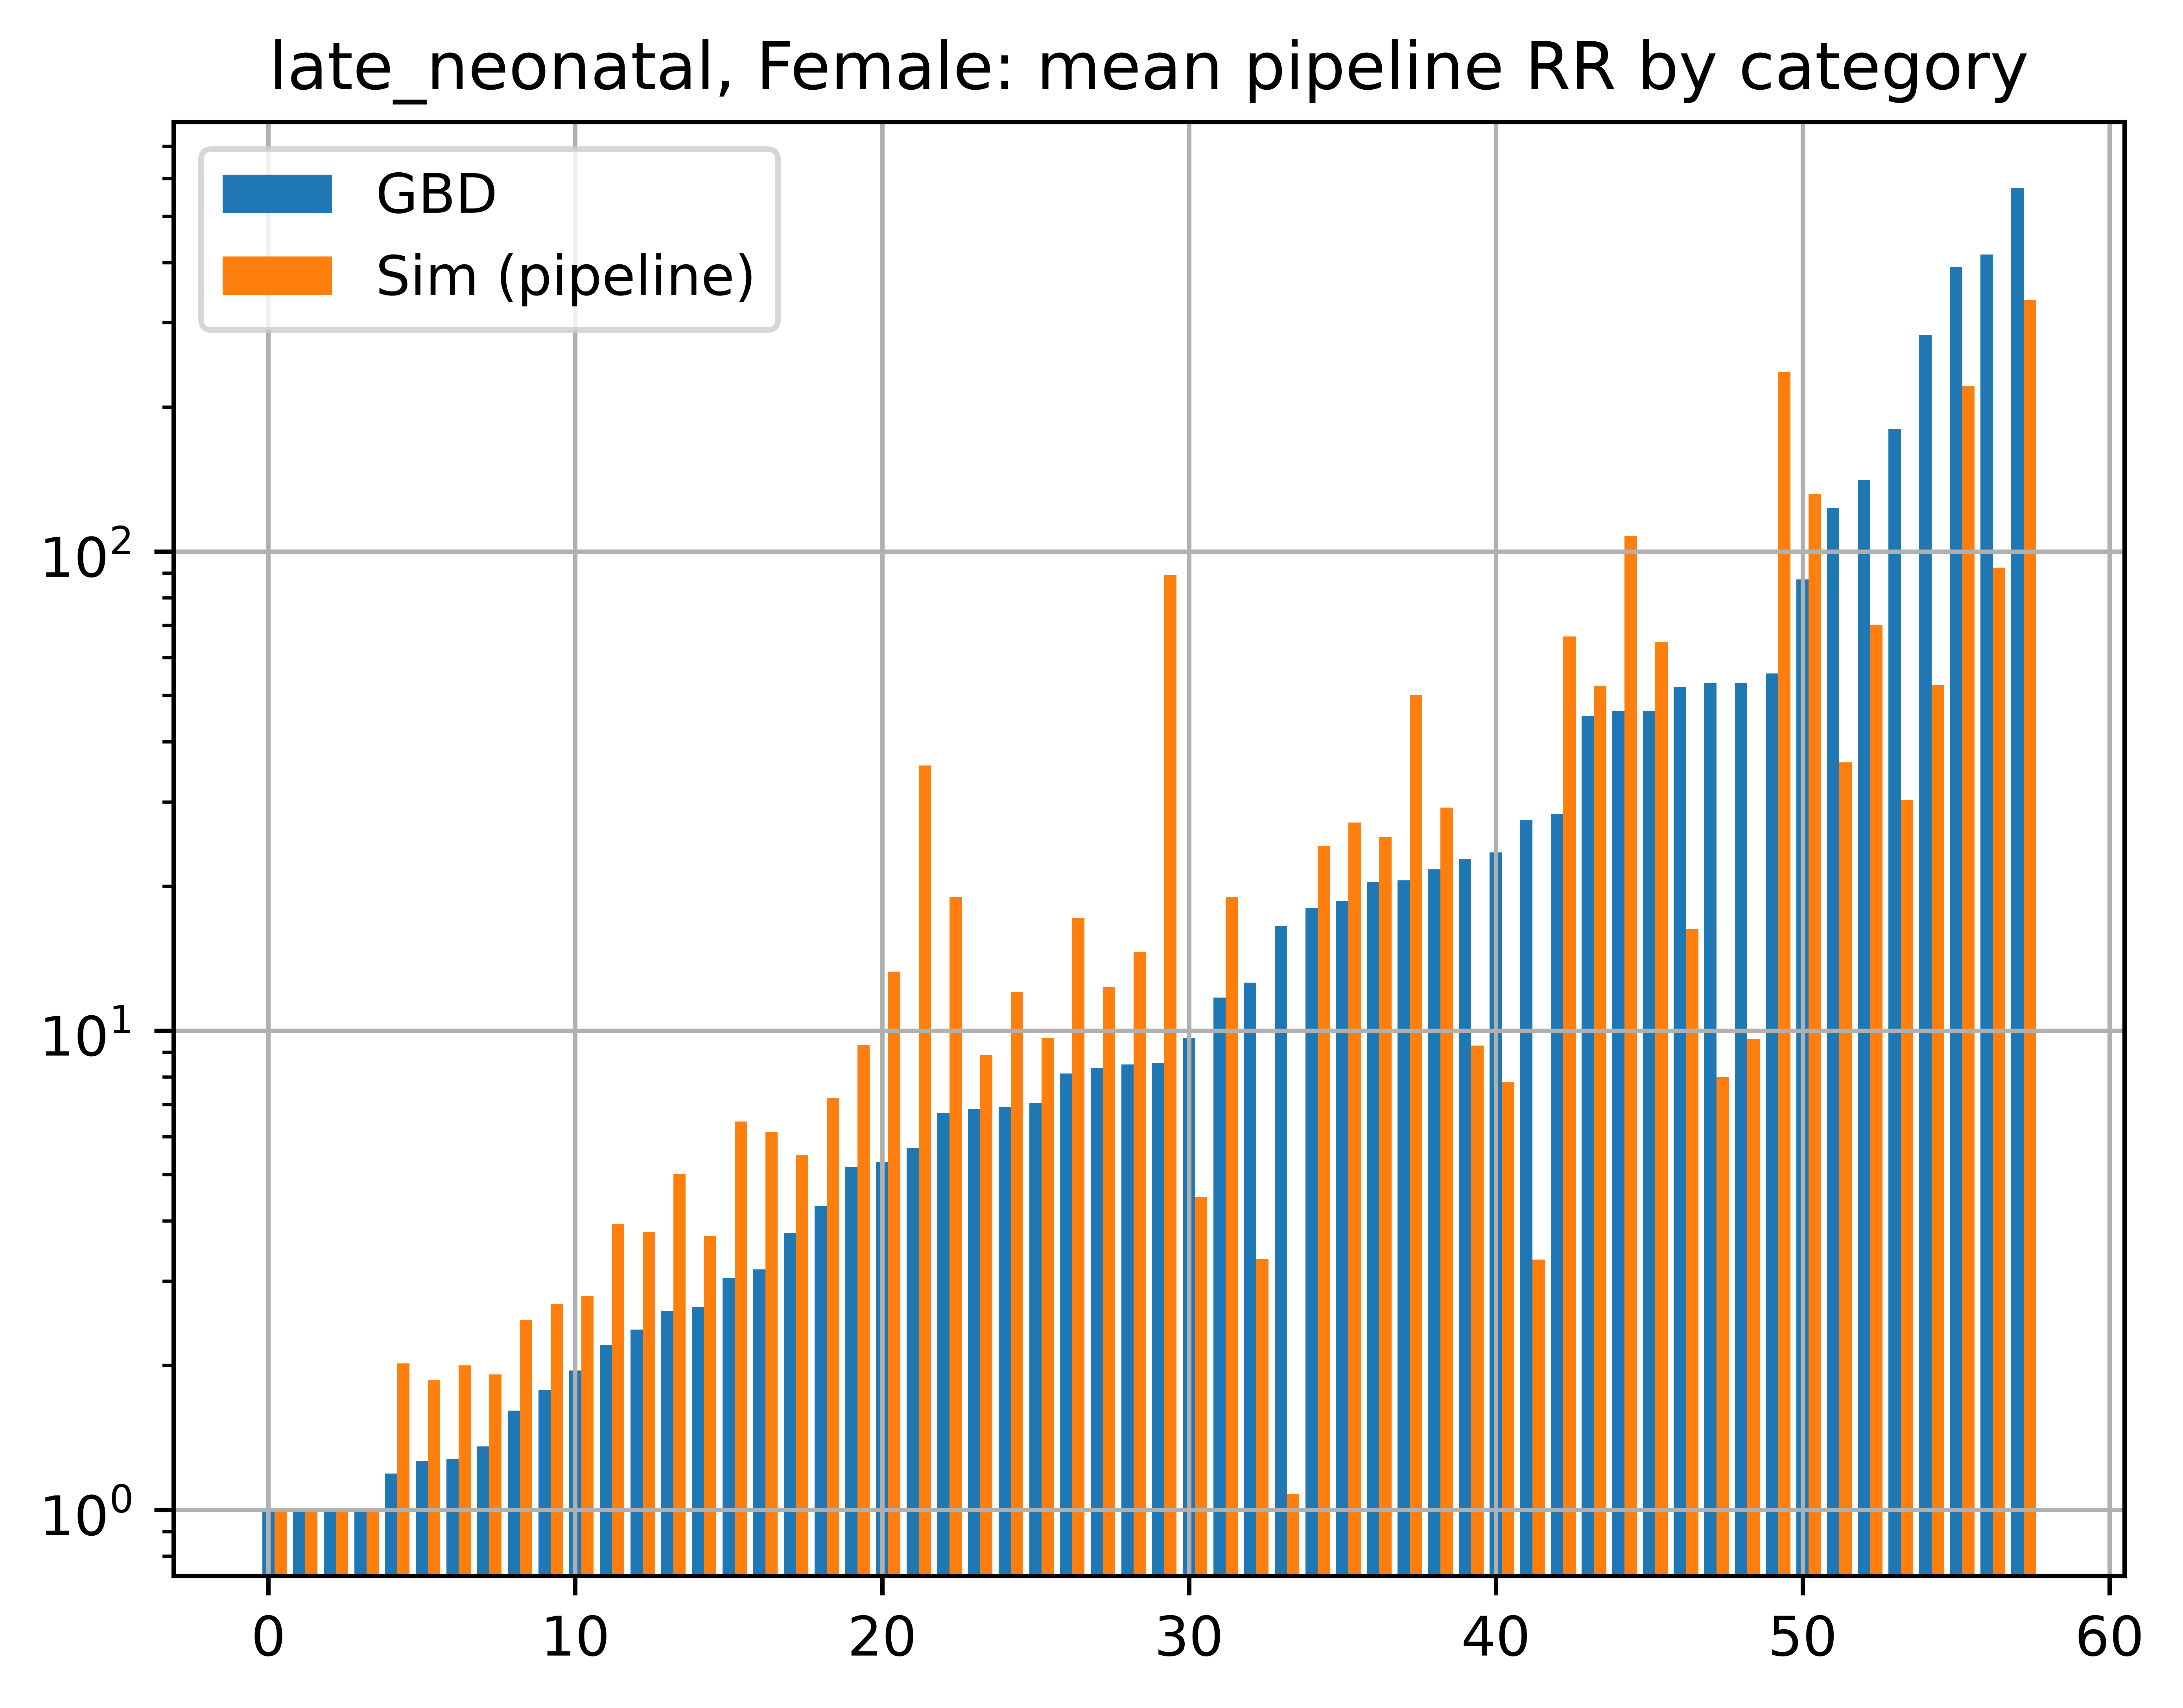

In [8]:
rr_art = art.load("risk_factor.low_birth_weight_and_short_gestation.relative_risk").reset_index()
age_starts = {"early_neonatal": 0.0, "late_neonatal": 0.019178}

for age_group, age_start in age_starts.items():
    rr_col = f"effect_of_low_birth_weight_and_short_gestation_on_{age_group}_affected_unmodeled_relative_risk"
    sim_rr = pop.groupby(["sex", "parameter"])[rr_col].mean().rename("sim").reset_index()
    art_rr = rr_art.loc[np.isclose(rr_art.age_start, age_start), ["sex", "parameter", "draw_0"]]
    p_all = sim_rr.merge(art_rr, on=["sex", "parameter"])
    for sex in ["Male", "Female"]:
        p = p_all.loc[p_all.sex == sex].sort_values("draw_0").reset_index()
        plt.figure(dpi=1000)
        plt.bar(p.index, p["draw_0"], width=width, label="GBD")
        plt.bar(p.index + width, p["sim"], width=width, label="Sim (pipeline)")
        plt.grid()
        plt.legend()
        plt.semilogy()
        plt.title(f"{age_group}, {sex}: mean pipeline RR by category")
        print(f"{age_group} {sex}: max |log(sim/GBD)| = {np.abs(np.log(p['sim'] / p['draw_0'])).max():.2f}")

**Fails as expected pre-fix.** The pipeline RRs disagree with the artifact by up to e^3.7 ~ 40x
and are not monotone in the GBD ordering: mid-risk categories spike above their GBD values while
the most severe categories undershoot (~900 vs ~400 at the top). This is the interpolator
scramble seen at the knots in `child_mortality.ipynb` (max |log error| 4.19). Post-fix, Sim
should track GBD with only a small residual from evaluating the interpolator at each simulant's
continuous (GA, BW) instead of at the category midpoint.

## 4. Empirical relative risks after running the sim (skipped)

Deaths by category over the neonatal period, relative to the TMREL categories. Skipped while the
pipeline check above fails -- empirical RRs would just inherit the scrambled interpolator. Flip
`RUN_EMPIRICAL` after the fix lands. (One seed gives ~a few hundred neonatal deaths, so compare
coarsely, not category-by-category.)

In [9]:
RUN_EMPIRICAL = False  # pipeline RR check fails pre-fix; enable after the interpolator fix

if RUN_EMPIRICAL:
    for _ in range(7):  # 7 x 4-day steps: through the early and late neonatal periods
        sim_baseline.step()
    end = sim_baseline.get_population(["cause_of_death"], include_untracked=True)
    died = ~end["cause_of_death"].isin(["not_dead", "stillborn"])
    risk = pd.concat([pop[["parameter"]], died.rename("died")], axis=1).groupby("parameter").died.mean()
    gbd_rr = rr_art.loc[np.isclose(rr_art.age_start, 0.0)].groupby("parameter").draw_0.mean()
    tmrel_risk = risk[gbd_rr[gbd_rr == 1].index.intersection(risk.index)].mean()
    emp = (risk / tmrel_risk).rename("empirical_rr").to_frame().join(gbd_rr.rename("gbd_rr"))
    print(emp.sort_values("gbd_rr").to_string())